[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MatheusSilveiraVicente/case-especialista-dados/blob/main/notebooks/03_modelagem.ipynb)

# 03 — Previsão de receita diária, 7 dias à frente

**Pergunta de negócio:** quanto vamos vender na próxima semana, com antecedência suficiente para a operação reagir?

**Resposta em 5 linhas**
1. Oito modelos competem nas mesmas origens: duas réguas simples, ETS, SARIMA, SARIMAX, Ridge, XGBoost e LightGBM.
2. A evidência principal reúne 16 semanas: LightGBM 21,7%, ETS 22,3% e SARIMA 22,0% de WAPE diário — empate prático.
3. O LightGBM permanece pela combinação de não inferioridade, viés menor nas 16 semanas e explicabilidade; não por superioridade de acurácia.
4. Junho ficou fora do ajuste e foi usado uma vez como diagnóstico na rodada 1; por isso não é chamado de "cego".
5. Recomendação: LightGBM monitorado contra média móvel e critério calendário B publicado para teste prospectivo.

Toda a lógica está em `src/`; este notebook só orquestra e lê os resultados.

In [1]:
# Setup: roda localmente ou no Google Colab
import os, subprocess, sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO = "MatheusSilveiraVicente/case-especialista-dados"

if IN_COLAB:
    pasta = Path("/content/case-especialista-dados")
    if not pasta.exists():
        url = f"https://github.com/{REPO}.git"
        subprocess.run(["git", "clone", "-q", url, str(pasta)], check=True, capture_output=True)
    os.chdir(pasta)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "optuna", "holidays", "shap", "lightgbm", "xgboost", "statsmodels", "pyarrow"], check=True)
    if not Path("data/raw/vendas.csv").exists():
        from google.colab import files
        print("Envie o CSV do case (Dados - Case Técnico Espec I.csv):")
        enviado = files.upload()
        Path("data/raw").mkdir(parents=True, exist_ok=True)
        Path(next(iter(enviado))).rename("data/raw/vendas.csv")
elif Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
print("Ambiente:", "Colab" if IN_COLAB else "local")

Ambiente: local


## Como rodar

Localmente, o notebook **lê os resultados já gerados** em `reports/`. No Colab, ele **treina do zero** (ajuste de parâmetros, walk-forward, junho, bootstrap, SHAP, figuras e faixa de previsão), o que leva alguns minutos em CPU. Para treinar localmente, mude `RETREINAR` para `True` (sobrescreve `reports/` e `data/processed/`). Com versões de bibliotecas diferentes, os números podem variar levemente.

In [2]:
RETREINAR = IN_COLAB  # no Colab, treina do zero para mostrar o processo

if RETREINAR:
    from src.train import main
    from src import intervalos
    main()
    intervalos.main()

## 0. O treinamento, visto semana a semana

A faixa azul é o que o modelo já viu; a laranja, a semana que ele prevê. A cada passo, ele retreina com tudo até ali. Abaixo, a versão interativa (arraste o controle) e como cada árvore corrige a anterior.

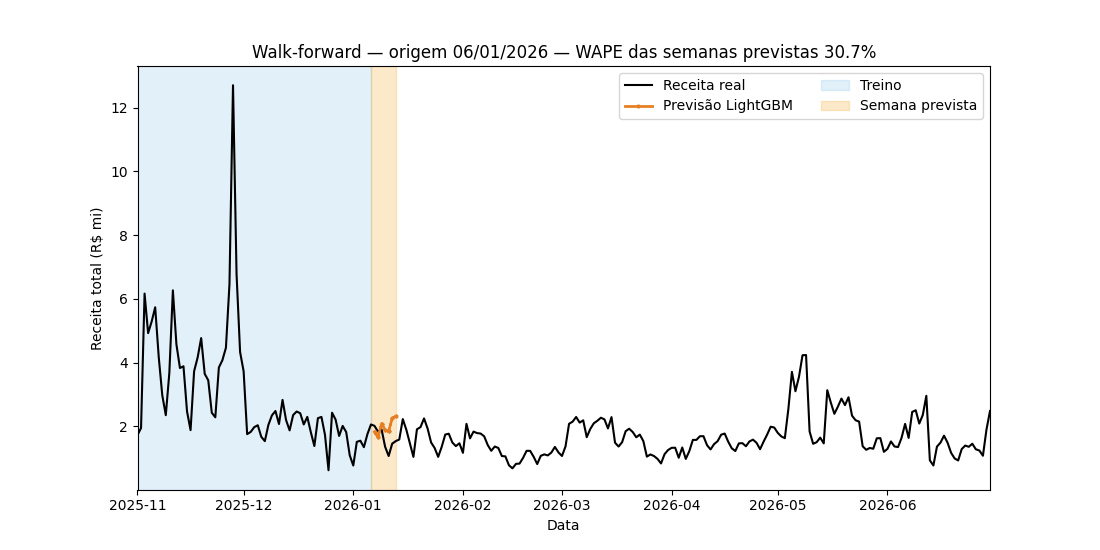

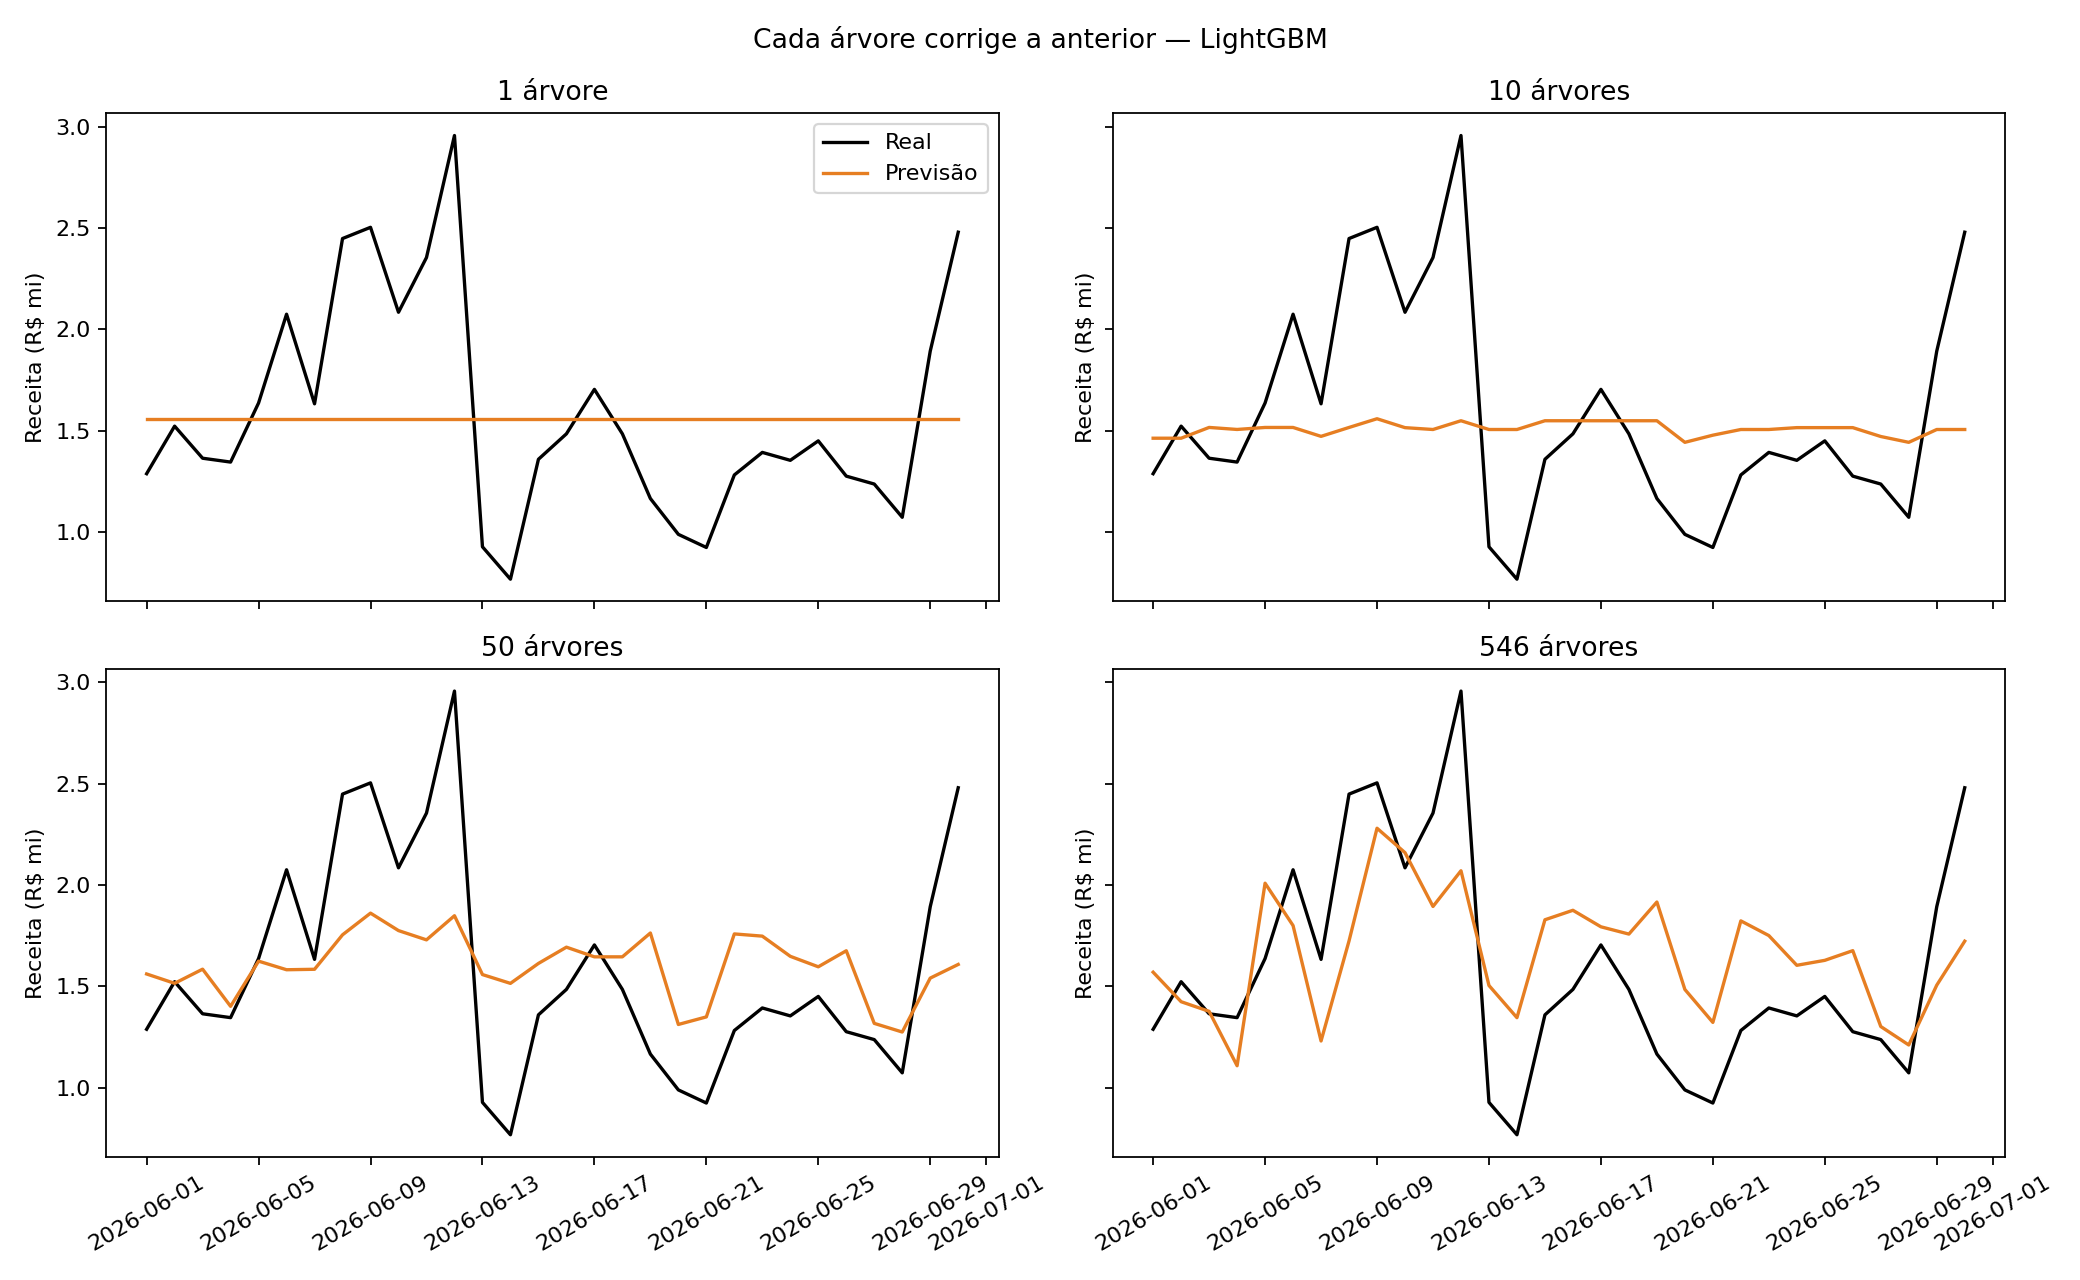

In [3]:
from IPython.display import HTML, Image, display
display(Image("reports/figures/walkforward.gif"))
display(HTML(Path("reports/figures/walkforward_interativo.html").read_text(encoding="utf-8")))
display(Image("reports/figures/boosting_passos.png"))

## 1. Torneio ampliado

Todos os modelos usam as mesmas origens e o mesmo alvo. ETS e SARIMA usam apenas o histórico disponível; SARIMAX acrescenta feriados e eventos conhecidos de antemão; os modelos de ML usam as features congeladas. O **WAPE** é a soma dos erros absolutos dividida pela receita real; o **viés** positivo indica superestimação.

In [4]:
import pandas as pd
from IPython.display import Image, display
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

metricas = pd.read_csv("reports/metrics/resumo_metricas.csv")
display(metricas.query("granularidade == 'total' and segmento == 'todos'")[["conjunto", "modelo", "wape", "bias", "mae", "wape_ic_low", "wape_ic_high"]].sort_values(["conjunto", "wape"]))

torneio_16 = pd.read_csv("reports/metrics/torneio_16_semanas.csv")
display(torneio_16.sort_values(["recorte", "wape_diario"]))

,conjunto,modelo,wape,bias,mae,wape_ic_low,wape_ic_high
141,holdout,xgboost,0.186,-0.006,"294,977.285",0.134,0.242
151,holdout,lightgbm,0.201,-0.005,"318,103.161",0.154,0.251
121,holdout,sarimax_log,0.205,-0.003,"324,823.580",0.140,0.274
101,holdout,ets_log,0.218,-0.104,"345,002.121",0.147,0.281
131,holdout,ridge,0.228,-0.025,"361,383.156",0.157,0.305
111,holdout,sarima_log,0.240,-0.046,"380,503.547",0.129,0.352
91,holdout,media_movel_7,0.312,-0.024,"493,771.032",0.136,0.473
81,holdout,naive_sazonal,0.351,-0.023,"555,337.492",0.147,0.529
31,walkforward,sarima_log,0.213,-0.104,"356,595.726",0.146,0.269
71,walkforward,lightgbm,0.223,-0.032,"374,078.324",0.158,0.286


,recorte,modelo,n_blocos,n_dias,wape_diario,vies,erro_semanal_semanas_cheias,erro_semanal_blocos_parciais
17,dezesseis_semanas,lightgbm,16,105,0.217,-0.024,0.140,0.149
21,dezesseis_semanas,sarima_log,16,105,0.220,-0.088,0.131,0.136
23,dezesseis_semanas,xgboost,16,105,0.220,-0.027,0.129,0.147
16,dezesseis_semanas,ets_log,16,105,0.223,-0.133,0.163,0.168
22,dezesseis_semanas,sarimax_log,16,105,0.234,-0.066,0.170,0.170
20,dezesseis_semanas,ridge,16,105,0.247,-0.099,0.183,0.188
18,dezesseis_semanas,media_movel_7,16,105,0.251,-0.030,0.177,0.196
19,dezesseis_semanas,naive_sazonal,16,105,0.320,-0.020,0.177,0.205
7,junho,xgboost,5,30,0.186,-0.006,0.097,0.113
1,junho,lightgbm,5,30,0.201,-0.005,0.101,0.118


**Leitura**
- Nas **16 semanas**, LightGBM (21,7%), ETS (22,3%) e SARIMA (22,0%) empatam em WAPE diário. O SARIMA tem o menor erro do total semanal; o LightGBM tem o menor viés entre eles.
- Em junho, fora do ajuste mas já usado como diagnóstico na rodada 1, XGBoost faz 18,6%, LightGBM 20,1%, SARIMAX 20,5% e ETS 21,8%.
- No walk-forward de avaliação, SARIMA faz 21,3%, LightGBM 22,3%, ETS 22,5% e média móvel 22,8%. A conclusão não depende do melhor recorte de junho.

## 2. Contraprova pareada

Para cada par de modelos, reamostro **semanas inteiras** dos mesmos dias e calculo a diferença de WAPE (A − B). Se o intervalo de 95% contém zero, é empate.

In [5]:
display(pd.read_csv("reports/metrics/contraprova.csv"))
display(pd.read_csv("reports/metrics/nao_inferioridade.csv"))
display(pd.read_csv("reports/metrics/vies_segmento.csv"))

,conjunto,modelo_a,modelo_b,diferenca,ic_low,ic_high,p_a_menor_b
0,walkforward,naive_sazonal,media_movel_7,0.081,0.014,0.158,0.001
1,walkforward,naive_sazonal,ets_log,0.084,0.009,0.171,0.011
2,walkforward,naive_sazonal,sarima_log,0.096,0.031,0.184,0.000
3,walkforward,naive_sazonal,sarimax_log,0.064,-0.014,0.165,0.068
4,walkforward,naive_sazonal,ridge,0.055,-0.029,0.146,0.122
5,walkforward,naive_sazonal,xgboost,0.076,-0.009,0.161,0.037
6,walkforward,naive_sazonal,lightgbm,0.086,-0.000,0.173,0.026
7,walkforward,media_movel_7,ets_log,0.003,-0.078,0.100,0.463
8,walkforward,media_movel_7,sarima_log,0.015,-0.048,0.098,0.314
9,walkforward,media_movel_7,sarimax_log,-0.016,-0.086,0.070,0.666


,tipo,recorte,modelo_a,modelo_b,diferenca,ic_low,ic_high,p_a_menor_b,n_blocos,mde_80
0,nao_inferioridade,dezesseis_semanas,lightgbm,media_movel_7,-0.034,-0.097,0.027,0.851,16,NaN
1,nao_inferioridade,dezesseis_semanas,lightgbm,ets_log,-0.006,-0.056,0.043,0.576,16,NaN
2,nao_inferioridade,dezesseis_semanas,lightgbm,sarima_log,-0.003,-0.045,0.046,0.551,16,NaN
3,nao_inferioridade,dezesseis_semanas,lightgbm,sarimax_log,-0.017,-0.049,0.022,0.819,16,NaN
4,mde_regra_original,junho,lightgbm,media_movel_7,-0.111,-0.239,0.024,0.956,5,0.190
5,mde_regra_original,walkforward_avaliacao,lightgbm,media_movel_7,-0.005,-0.076,0.057,0.546,11,0.096


,modelo,conjunto,segmento,vies
0,naive_sazonal,walkforward_avaliacao,evento/janela de evento,-0.278
1,naive_sazonal,walkforward_avaliacao,dia normal,0.028
2,media_movel_7,walkforward_avaliacao,evento/janela de evento,-0.294
3,media_movel_7,walkforward_avaliacao,dia normal,0.016
4,ets_log,walkforward_avaliacao,evento/janela de evento,-0.198
5,ets_log,walkforward_avaliacao,dia normal,-0.134
6,sarima_log,walkforward_avaliacao,evento/janela de evento,-0.241
7,sarima_log,walkforward_avaliacao,dia normal,-0.079
8,sarimax_log,walkforward_avaliacao,evento/janela de evento,-0.293
9,sarimax_log,walkforward_avaliacao,dia normal,-0.053


**Leitura**
- Nas 16 semanas, LightGBM − média móvel tem IC 95% com limite superior próximo de +2,7 p.p.; contra ETS e SARIMA os intervalos também contêm zero. A evidência é de **não inferioridade**, não de vitória.
- A diferença mínima detectável da regra original é cerca de 19 p.p. em junho e 9,5 p.p. no walk-forward: havia pouco poder para separar modelos próximos.
- O viés agregado quase zero em junho é compensação: o LightGBM subestima janelas de evento e superestima dias normais. A tabela torna essa assimetria explícita.

## 3. A decisão: não inferioridade + viés + explicabilidade

A regra foi fixada antes da rodada final, depois de junho já ter sido usado uma vez como diagnóstico. O `decisao.json` registra o resultado literal com os oito modelos. Como os intervalos são largos, a decisão de negócio usa as 16 semanas: não inferioridade, menor viés e capacidade de explicar variáveis.

As viradas por venda observada são apenas diagnóstico ex post. Para teste prospectivo, os critérios A e B abaixo são definidos por calendário, antes de observar a receita.

In [6]:
import json
from pathlib import Path
display(json.loads(Path("reports/metrics/decisao.json").read_text(encoding="utf-8")))

semanas = pd.read_csv("reports/metrics/erro_por_semana.csv")
display(semanas[["conjunto", "inicio", "fim", "virada_nivel", "lightgbm", "xgboost", "media_movel_7", "naive_sazonal"]].sort_values("virada_nivel"))

grande = semanas["virada_nivel"] >= semanas["virada_nivel"].median()
display(pd.DataFrame({
    "semanas": [grande.sum(), (~grande).sum()],
    "lightgbm": [semanas.loc[grande, "lightgbm"].mean(), semanas.loc[~grande, "lightgbm"].mean()],
    "media_movel_7": [semanas.loc[grande, "media_movel_7"].mean(), semanas.loc[~grande, "media_movel_7"].mean()],
}, index=["venda muda de patamar", "semana estável"]))

display(pd.read_csv("reports/metrics/viradas_calendario.csv"))

{'holdout': {'candidato': 'xgboost',
  'empates': ['media_movel_7', 'ets_log', 'sarima_log', 'sarimax_log'],
  'vencedor': 'media_movel_7'},
 'walkforward': {'candidato': 'sarima_log',
  'empates': ['media_movel_7'],
  'vencedor': 'media_movel_7'},
 'walkforward_concorda': True,
 'regra4_vencedor': 'media_movel_7',
 'poder_estatistico': {'holdout': {'n_blocos_semanas': 5,
   'semi_largura_media_ic95_diferenca_wape': 0.07387927133784127},
  'walkforward': {'n_blocos_semanas': 11,
   'semi_largura_media_ic95_diferenca_wape': 0.06645031533446992}}}

,conjunto,inicio,fim,virada_nivel,lightgbm,xgboost,media_movel_7,naive_sazonal
14,holdout,2026-06-22,2026-06-28,0.005,0.133,0.142,0.069,0.117
2,walkforward,2026-02-04,2026-02-10,0.011,0.135,0.121,0.136,0.210
7,walkforward,2026-04-15,2026-04-21,0.011,0.089,0.108,0.102,0.062
1,walkforward,2026-01-21,2026-01-27,0.079,0.185,0.179,0.219,0.205
0,walkforward,2026-01-07,2026-01-13,0.108,0.307,0.330,0.179,0.329
11,holdout,2026-06-01,2026-06-07,0.121,0.157,0.111,0.137,0.124
5,walkforward,2026-03-18,2026-03-24,0.125,0.065,0.075,0.142,0.213
3,walkforward,2026-02-18,2026-02-24,0.147,0.344,0.276,0.161,0.212
9,walkforward,2026-05-13,2026-05-19,0.153,0.264,0.241,0.218,0.548
6,walkforward,2026-04-01,2026-04-07,0.182,0.225,0.239,0.184,0.166


,semanas,lightgbm,media_movel_7
venda muda de patamar,8,0.258,0.369
semana estável,8,0.177,0.143


,criterio,grupo_com_data,modelo,n_semanas,wape
0,criterio_a,True,lightgbm,10,0.235
1,criterio_a,True,media_movel_7,10,0.245
2,criterio_a,False,lightgbm,6,0.181
3,criterio_a,False,media_movel_7,6,0.263
4,criterio_b,True,lightgbm,8,0.223
5,criterio_b,True,media_movel_7,8,0.289
6,criterio_b,False,lightgbm,8,0.208
7,criterio_b,False,media_movel_7,8,0.198


**Leitura**
- A classificação ex post de "virada" é frágil e não orienta decisão prospectiva. Pelos critérios de calendário, não há ganho robusto em todas as semanas com data.
- No critério B (data comercial a até sete dias), o LightGBM supera a média móvel no grupo com data; nas demais semanas a média móvel pode ser melhor. Isso é uma hipótese para Dia dos Pais e Black Friday, não uma conclusão causal.
- **Decisão:** LightGBM por não inferioridade nas 16 semanas, viés menor que ETS/SARIMA e explicabilidade. A média móvel segue como régua e gatilho de reversão.

## 4. O que pesou na previsão

Duas medidas complementares:
- **SHAP:** quanto cada variável move a previsão, em média (o que o modelo *usa*).
- **Permutação (30 repetições, junho):** quanto o erro piora quando a variável é embaralhada (o que o modelo *precisa* para acertar).

,feature,shap_abs_medio
0,media_7_lag7,"174,742.554"
1,canal,"110,625.365"
2,lag_7,"109,796.854"
3,share_canal_lag7,"62,156.646"
4,dias_ate_evento_presente,"44,360.043"
5,is_fim_semana,"40,096.406"
6,dias_ate_evento_promo,"38,951.791"
7,fourier_mes_sin1,"34,082.764"


,feature,aumento_wape_media,aumento_wape_std
0,dias_ate_evento_presente,0.067,0.019
1,media_7_lag7,0.052,0.022
2,lag_7,0.047,0.018
3,fourier_mes_sin1,0.024,0.010
4,taxa_desconto_media_7_lag7,0.017,0.011
5,canal,0.017,0.016
6,share_canal_lag7,0.014,0.014
7,std_7_lag7,0.006,0.006


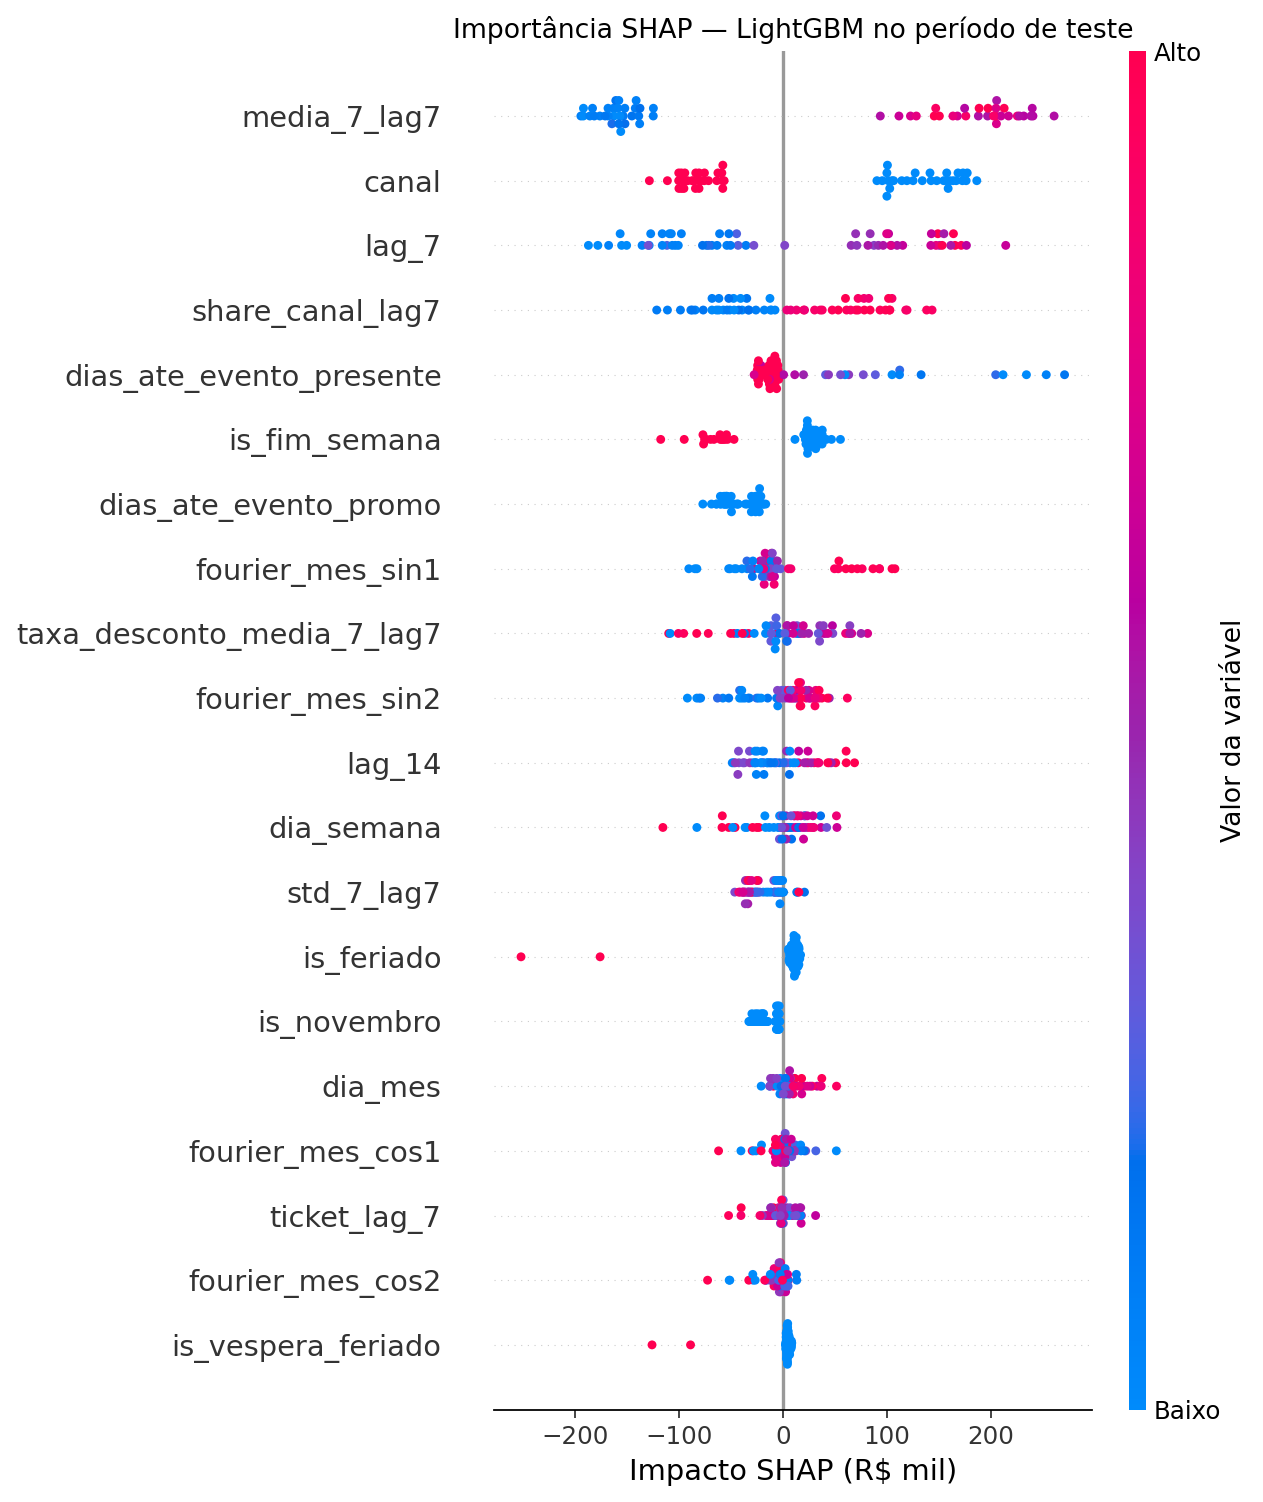

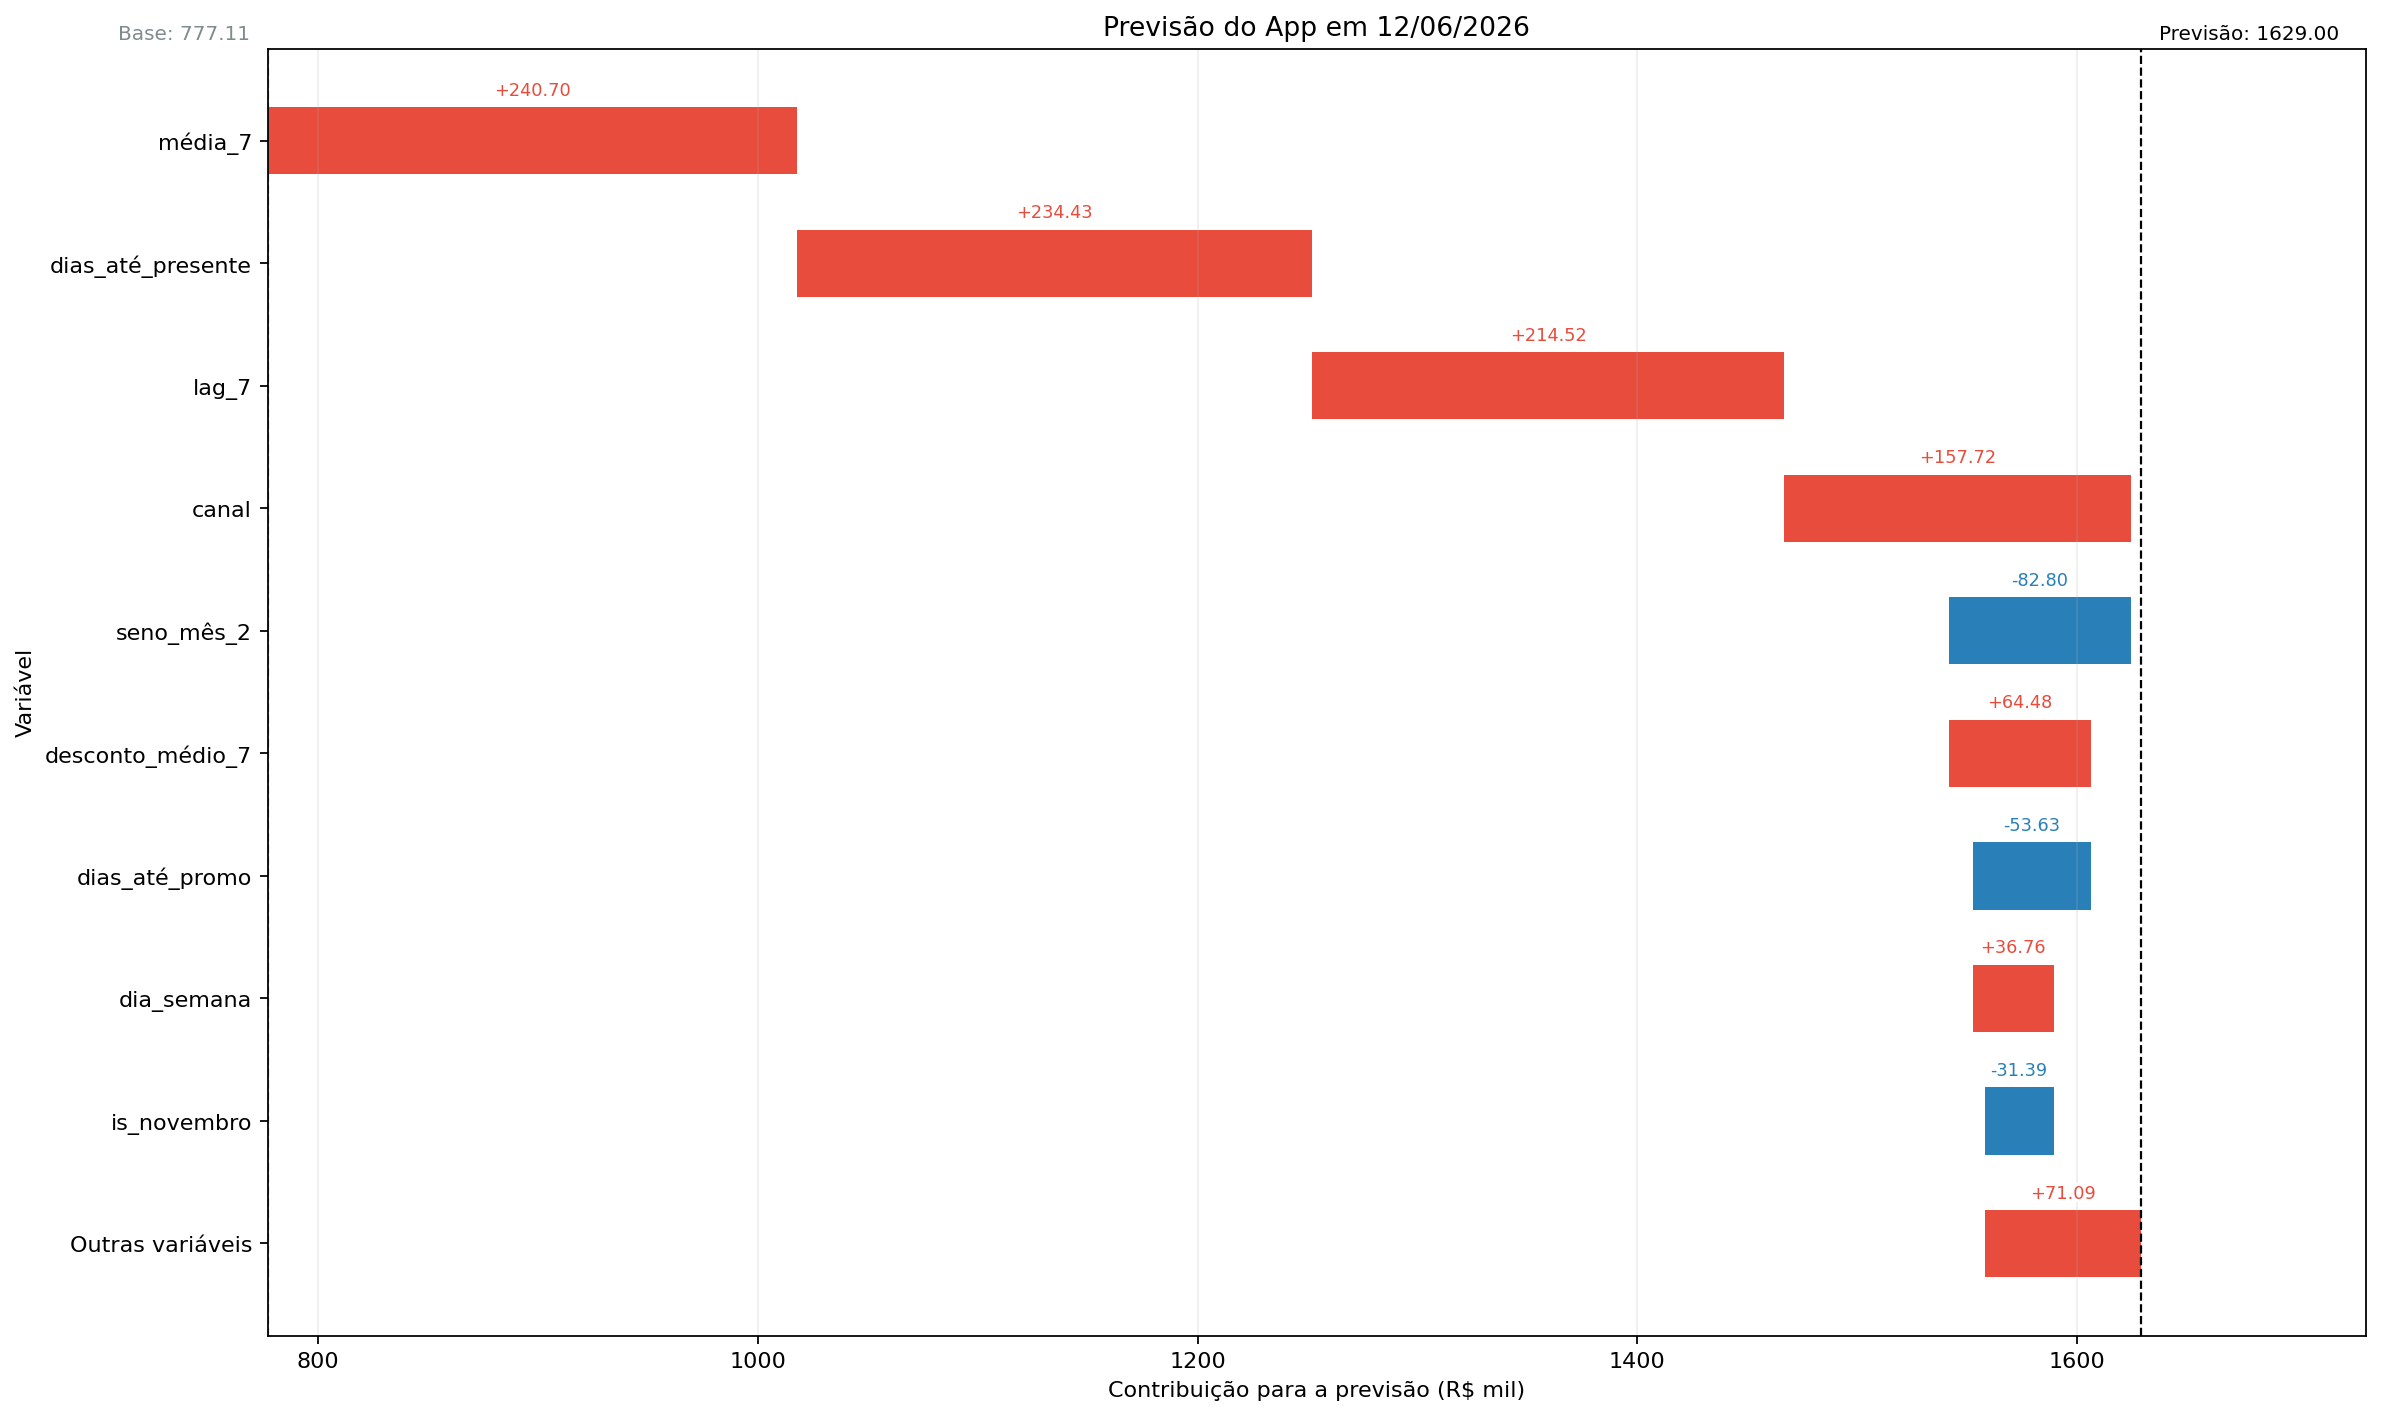

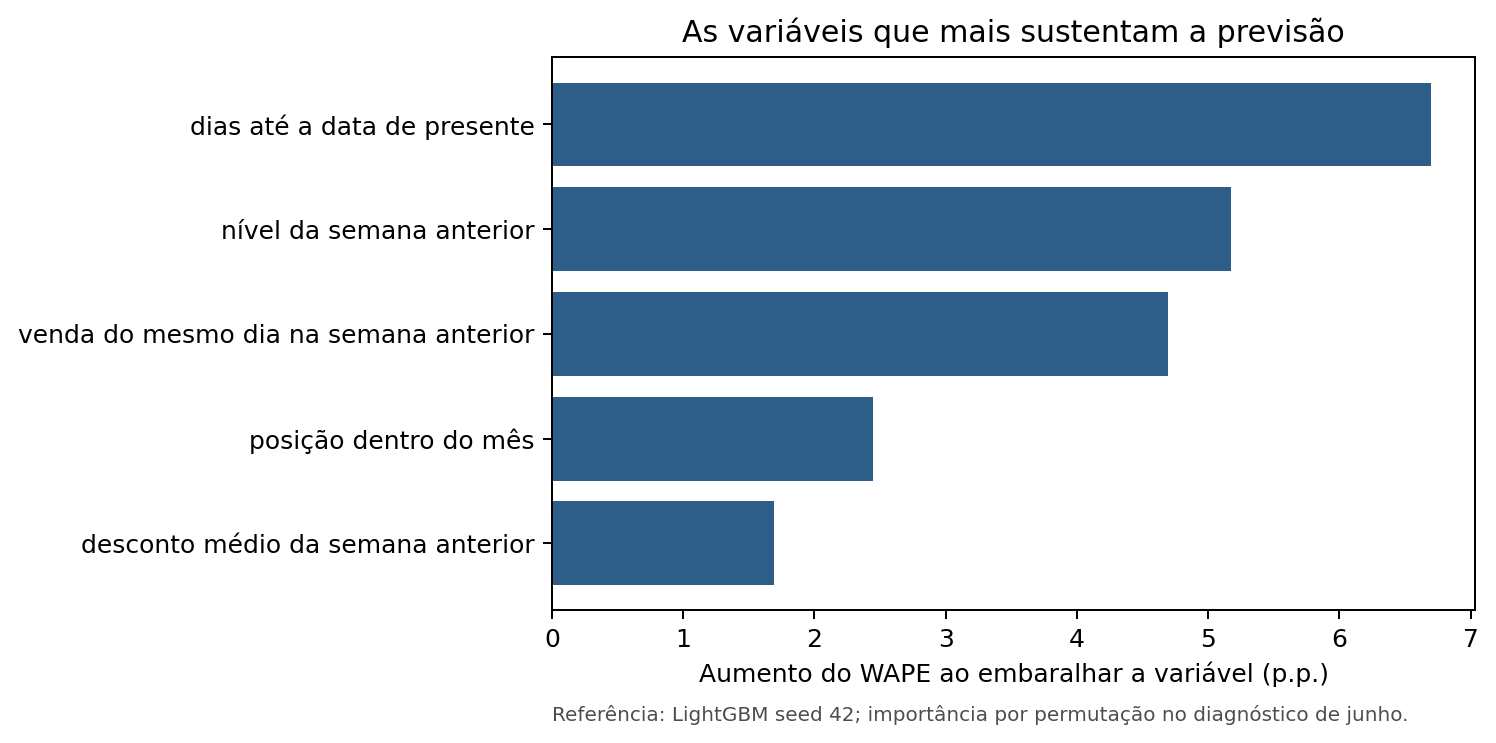

In [7]:
shap = pd.read_csv("reports/metrics/shap_importancia.csv").head(8)
perm = pd.read_csv("reports/metrics/permutation_importance.csv").query("modelo == 'lightgbm'").sort_values("aumento_wape_media", ascending=False).head(8)
display(shap); display(perm[["feature", "aumento_wape_media", "aumento_wape_std"]])
display(Image("reports/figures/shap_summary.png"))
display(Image("reports/figures/shap_waterfall_namorados.png"))
display(Image("reports/figures/importancia_negocio.png"))

**Leitura**
- O nível da semana anterior sustenta a previsão; dia da semana pesa pouco porque esse padrão já está embutido no `lag_7`.
- Proximidade de data de presente lidera a permutação, mas foi aprendida com poucas datas e ajudou sobretudo no Dia dos Namorados. É uma limitação a monitorar.
- A figura de negócio usa **LightGBM seed 42** como referência (WAPE 19,1% em junho), não o ensemble de cinco seeds (20,1%).
- SHAP e permutação respondem perguntas diferentes: canal move a escala no SHAP, mas pode ser substituído por participação recente na permutação.

## 5. Quanto o modelo agrega e quão incerta é a previsão

Gerado por `python -m src.intervalos`.

,modelo,conjunto,wape,fva_vs_naive,fva_vs_media_movel,wape_semanal,bias_semanal
0,ets_log,walkforward,0.225,0.272,0.015,0.190,-0.144
1,lightgbm,walkforward,0.223,0.278,0.022,0.161,-0.032
2,media_movel_7,walkforward,0.228,0.262,0.000,0.182,-0.032
3,naive_sazonal,walkforward,0.309,0.000,-0.354,0.194,-0.019
4,ridge,walkforward,0.253,0.180,-0.111,0.202,-0.127
5,sarima_log,walkforward,0.213,0.312,0.068,0.154,-0.104
6,sarimax_log,walkforward,0.245,0.209,-0.072,0.203,-0.090
7,xgboost,walkforward,0.233,0.245,-0.022,0.160,-0.034
8,ets_log,holdout,0.218,0.379,0.301,0.110,-0.104
9,lightgbm,holdout,0.201,0.427,0.356,0.118,-0.005


,conjunto,nivel,cobertura,largura_media_rs,largura_media_pct,pinball_p10,pinball_p90,n_dias,metodo,folga_log
0,walkforward,total,0.467,"660,118.405",0.427,"80,676.841","133,685.250",75,quantilico,NaN
3,walkforward,total,0.933,"1,565,228.278",0.997,"71,031.823","103,587.092",75,conformal,0.269
4,holdout,total,0.633,"759,696.772",0.492,"76,584.042","121,107.462",30,quantilico,NaN
7,holdout,total,0.900,"1,652,623.028",1.069,"68,382.118","99,487.867",30,conformal,0.269


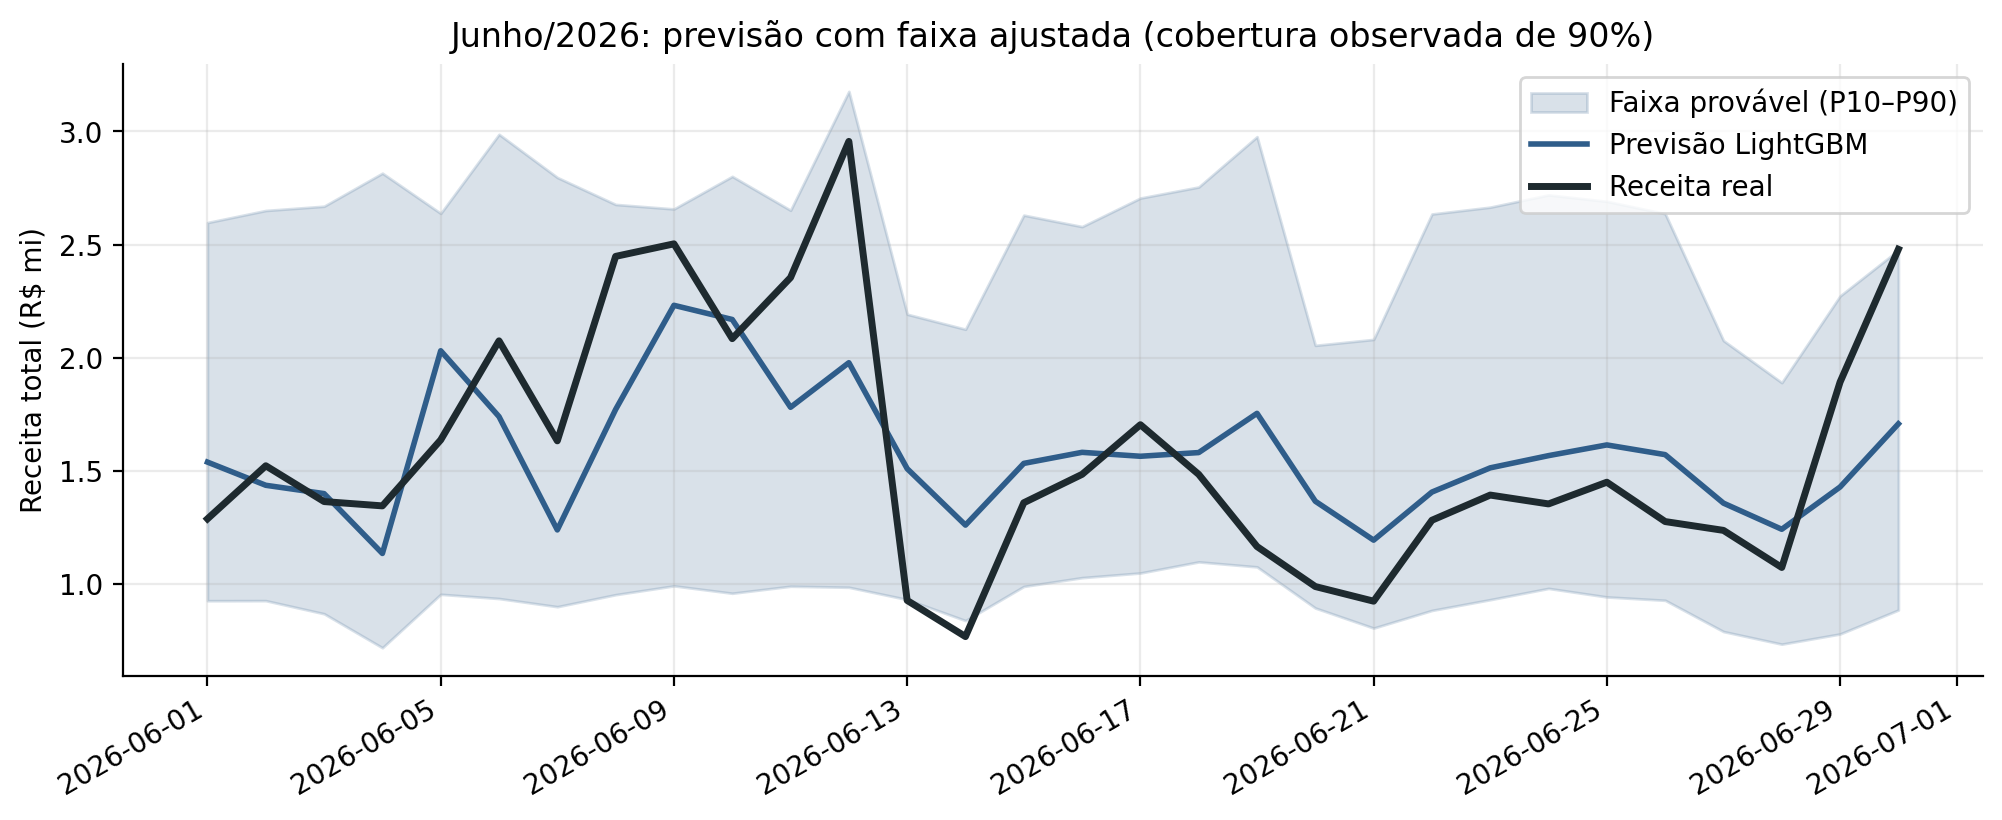

,recorte,modelo_referencia,n_blocos,n_semanas_cheias,quantil_10_erro_relativo,quantil_90_erro_relativo,cobertura,p80_erro_absoluto_semanal
0,ajuste,lightgbm_seed_42,11,11,-0.353,0.362,0.818,0.358
1,walkforward_avaliacao,lightgbm_seed_42,11,10,-0.353,0.362,0.909,0.228
2,junho,lightgbm_seed_42,5,4,-0.353,0.362,0.800,0.114
3,dezesseis_semanas,lightgbm_seed_42,16,14,-0.353,0.362,0.875,0.215
4,vinte_cinco_semanas,lightgbm_seed_42,27,25,-0.353,0.362,0.852,0.287


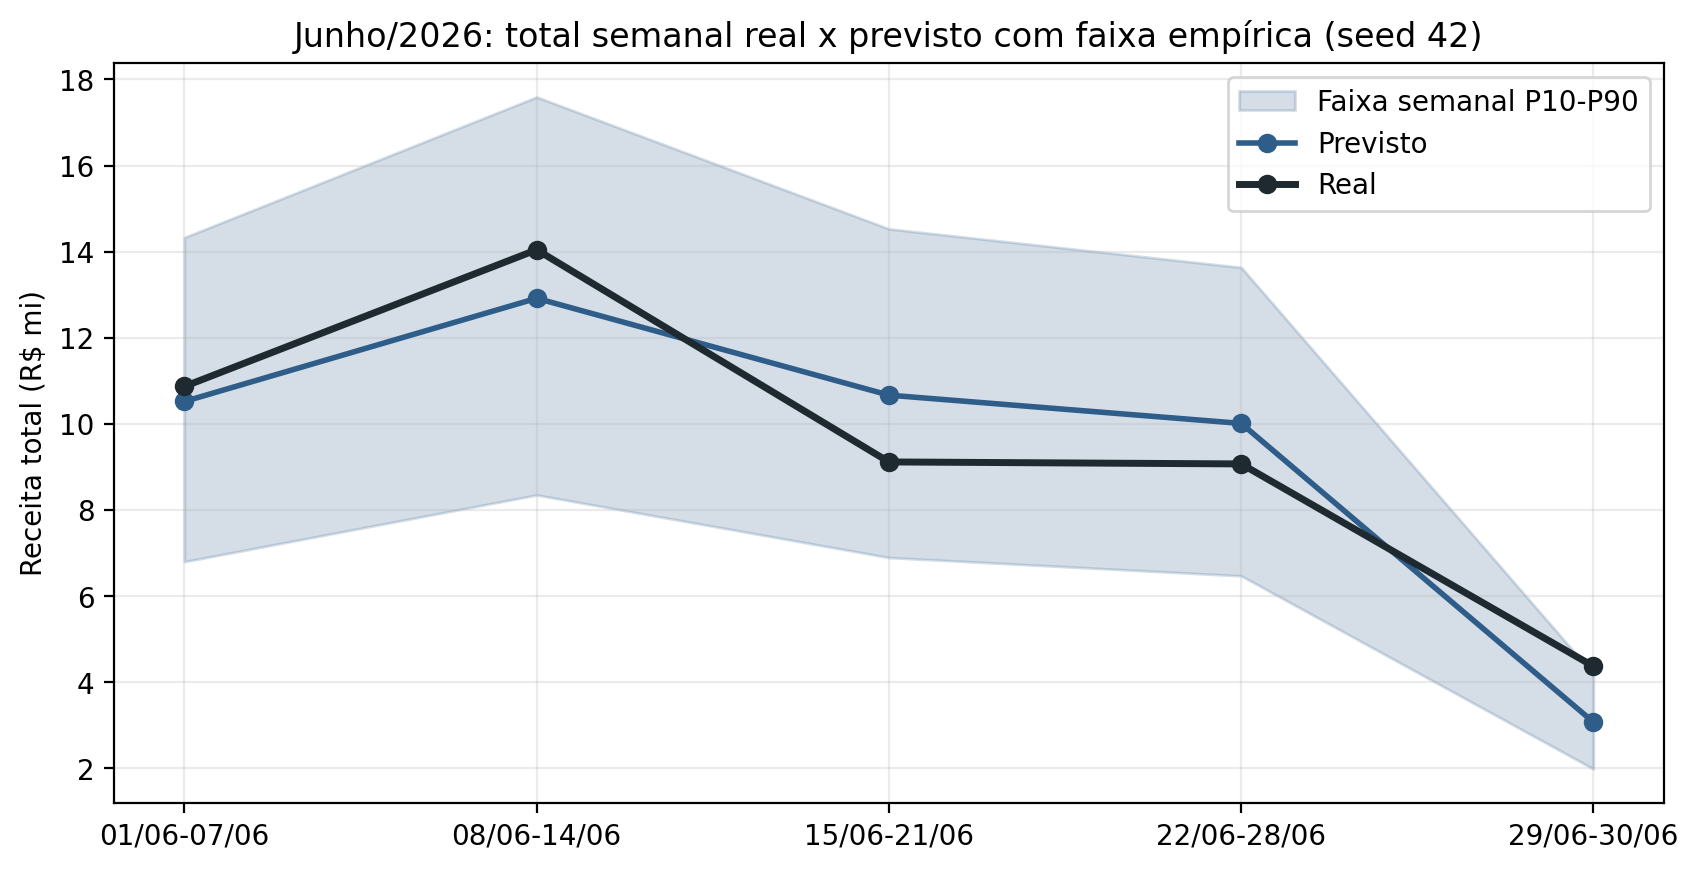

In [8]:
extras = pd.read_csv("reports/metrics/metricas_extras.csv")
display(extras[["modelo", "conjunto", "wape", "fva_vs_naive", "fva_vs_media_movel", "wape_semanal", "bias_semanal"]])
display(pd.read_csv("reports/metrics/intervalos.csv").query("nivel == 'total'"))
display(Image("reports/figures/intervalo_holdout.png"))
display(pd.read_csv("reports/metrics/faixa_semanal.csv"))
display(Image("reports/figures/faixa_semanal_holdout.png"))

**Leitura**
- Nas 16 semanas, o LightGBM reduz modestamente o WAPE diário contra a média móvel; o ganho grande de junho não deve virar manchete geral.
- Em junho, o erro do total semanal é 10,1% nas quatro semanas cheias; incluindo o bloco parcial de dois dias, 11,8%. No walk-forward é cerca de 16%.
- A faixa semanal empírica é calibrada nas 11 semanas de ajuste pelos quantis P10 e P90 do erro relativo. A tabela informa cobertura no walk-forward e em junho.
- O P80 do erro absoluto nas 25 semanas cheias é a folga operacional conservadora. A faixa diária ajustada cobre cerca de 90%, apesar de o título antigo dizer 80%; ela é larga, então o planejamento deve partir do total semanal.

## 6. Combinação: total SARIMA e perfil LightGBM

O total de cada bloco e canal vem do SARIMA; a participação de cada dia vem do ensemble LightGBM identificado por `seed=-1`, média das seeds 42–46.

,recorte,modelo,wape_diario,vies,erro_semanal_semanas_cheias,erro_semanal_blocos_parciais
0,junho,sarima_log,0.240,-0.046,0.061,0.086
1,junho,lightgbm,0.201,-0.005,0.101,0.118
2,junho,combinacao,0.188,-0.046,0.061,0.086
3,junho,media_movel_7,0.312,-0.024,0.216,0.234
4,walkforward_avaliacao,sarima_log,0.213,-0.104,0.157,0.154
5,walkforward_avaliacao,lightgbm,0.223,-0.032,0.154,0.161
6,walkforward_avaliacao,combinacao,0.213,-0.104,0.157,0.154
7,walkforward_avaliacao,media_movel_7,0.228,-0.032,0.162,0.182
8,dezesseis_semanas,sarima_log,0.220,-0.088,0.131,0.136
9,dezesseis_semanas,lightgbm,0.217,-0.024,0.140,0.149


,recorte,modelo,diferenca_wape_combinacao_menos_modelo,ic95_diferenca_wape_low,ic95_diferenca_wape_high,p_combinacao_menor
0,junho,sarima_log,-0.052,-0.112,0.021,0.920
1,junho,lightgbm,-0.013,-0.040,0.011,0.828
4,walkforward_avaliacao,sarima_log,0.000,-0.024,0.032,0.487
5,walkforward_avaliacao,lightgbm,-0.010,-0.061,0.036,0.679
8,dezesseis_semanas,sarima_log,-0.014,-0.042,0.015,0.822
9,dezesseis_semanas,lightgbm,-0.011,-0.048,0.024,0.728


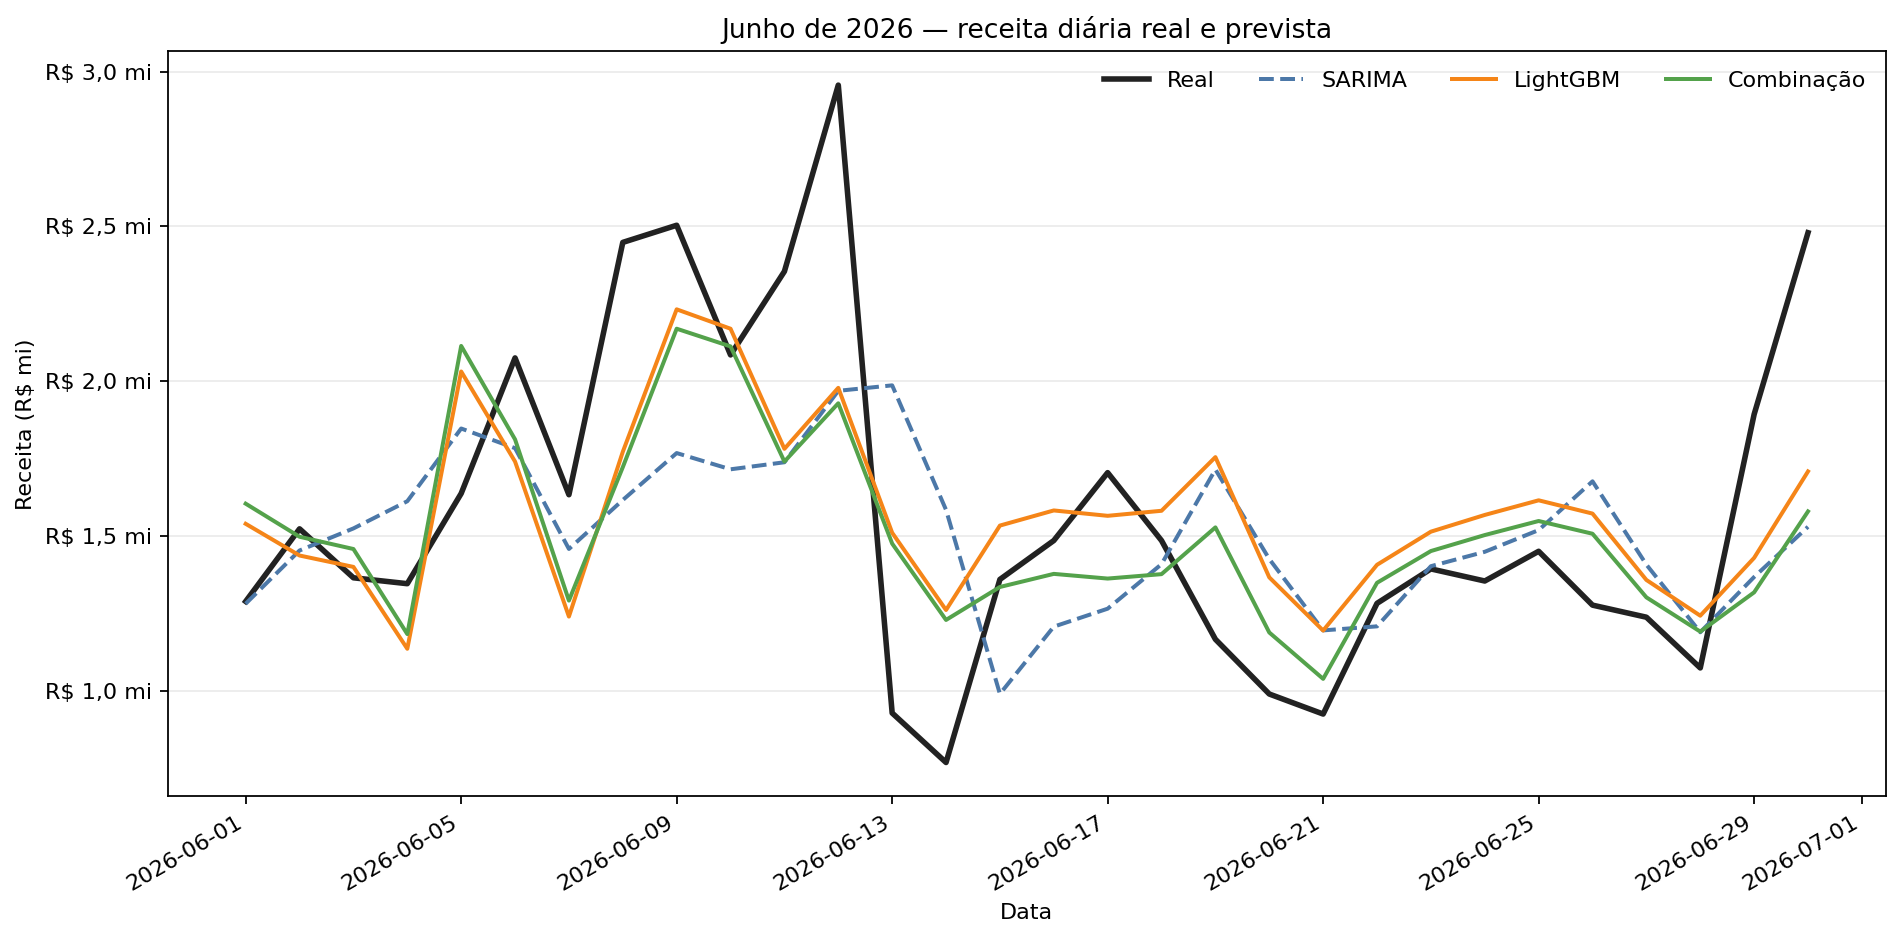

In [9]:
combinacao = pd.read_csv("reports/metrics/combinacao.csv")
metricas_combinacao = ["recorte", "modelo", "wape_diario", "vies", "erro_semanal_semanas_cheias", "erro_semanal_blocos_parciais"]
display(combinacao[metricas_combinacao])
display(combinacao.loc[combinacao["modelo"].isin(["sarima_log", "lightgbm"]), ["recorte", "modelo", "diferenca_wape_combinacao_menos_modelo", "ic95_diferenca_wape_low", "ic95_diferenca_wape_high", "p_combinacao_menor"]])
display(Image("reports/figures/combinacao_holdout.png"))

**Leitura**
- Nas 16 semanas, a combinação tem WAPE diário de 20,62%, contra 21,71% do LightGBM e 22,03% do SARIMA. Os ICs da diferença cruzam zero tanto contra o LightGBM (−1,08 p.p.; IC 95% [−4,77; +2,37]) quanto contra o SARIMA (−1,41 p.p.; IC 95% [−4,21; +1,45]); portanto, a vantagem numérica não demonstra superioridade estatística.
- No erro semanal das 16 semanas, a combinação preserva por construção o SARIMA: 13,14% nas semanas cheias e 13,58% incluindo blocos parciais, abaixo dos 13,95% e 14,91% do LightGBM. Esse ganho sobre o LightGBM não é uniforme: nas semanas cheias do walk-forward, a combinação fica em 15,70%, ligeiramente acima dos 15,35% do LightGBM.
- Em junho, a combinação melhora numericamente os dois puros no erro diário (18,80%, contra 20,10% do LightGBM e 24,04% do SARIMA). No walk-forward, empata na prática com o SARIMA (21,31% contra 21,27%) e melhora o LightGBM (22,31%).
- Resposta operacional: nas 16 semanas, a combinação supera numericamente o LightGBM no erro semanal e o SARIMA no erro diário, mas a evidência de erro diário ainda é inconclusiva; a dupla deve ser apresentada como divisão de papéis medida, não como ganho estatisticamente comprovado.

## 7. Diagnósticos complementares

### Erro semanal com intervalo de confiança

O bloco de reamostragem é a semana; quando o intervalo contém zero, a diferença entre os modelos não é demonstrável.

In [10]:
contraprova_semanal = pd.read_csv("reports/metrics/contraprova_semanal.csv")
display(contraprova_semanal.query("recorte == 'dezesseis_semanas'"))

,recorte,modelo_a,modelo_b,wape_semanal_a,wape_semanal_b,diferenca,ic_low,ic_high,p_a_menor_b,n_semanas_cheias
14,dezesseis_semanas,lightgbm,naive_sazonal,0.140,0.177,-0.037,-0.106,0.030,0.851,14
15,dezesseis_semanas,lightgbm,media_movel_7,0.140,0.177,-0.037,-0.106,0.030,0.851,14
16,dezesseis_semanas,lightgbm,ets_log,0.140,0.163,-0.023,-0.092,0.038,0.737,14
17,dezesseis_semanas,lightgbm,sarima_log,0.140,0.131,0.008,-0.043,0.064,0.382,14
18,dezesseis_semanas,lightgbm,sarimax_log,0.140,0.170,-0.031,-0.078,0.020,0.882,14
19,dezesseis_semanas,lightgbm,ridge,0.140,0.183,-0.044,-0.090,0.012,0.939,14
20,dezesseis_semanas,lightgbm,xgboost,0.140,0.129,0.011,-0.006,0.028,0.100,14


### Erro por antecedência

O recorte mostra o LightGBM e os dois modelos com WAPE médio por horizonte mais próximo em cada conjunto, de D+1 a D+7.

In [11]:
erro_horizonte = pd.read_csv("reports/metrics/erro_por_horizonte.csv")
for conjunto in erro_horizonte["conjunto"].drop_duplicates():
    recorte = erro_horizonte.query("conjunto == @conjunto")
    medias = recorte.groupby("modelo")["wape"].mean()
    proximos = (medias.drop("lightgbm") - medias.loc["lightgbm"]).abs().nsmallest(2).index
    modelos = ["lightgbm", *proximos]
    display(recorte.loc[recorte["modelo"].isin(modelos)].sort_values(["horizonte", "modelo"]))

,modelo,conjunto,horizonte,wape,bias,n_dias
0,ets_log,walkforward,1,0.109,-0.109,11
7,lightgbm,walkforward,1,0.210,-0.042,11
14,media_movel_7,walkforward,1,0.304,-0.040,11
1,ets_log,walkforward,2,0.185,-0.185,11
8,lightgbm,walkforward,2,0.184,-0.031,11
15,media_movel_7,walkforward,2,0.288,-0.039,11
2,ets_log,walkforward,3,0.210,-0.086,11
9,lightgbm,walkforward,3,0.189,-0.022,11
16,media_movel_7,walkforward,3,0.162,-0.077,11
3,ets_log,walkforward,4,0.266,-0.202,11


,modelo,conjunto,horizonte,wape,bias,n_dias
63,lightgbm,holdout,1,0.204,-0.071,5
84,ridge,holdout,1,0.268,-0.052,5
98,sarimax_log,holdout,1,0.191,-0.148,5
64,lightgbm,holdout,2,0.143,-0.097,5
85,ridge,holdout,2,0.258,-0.135,5
99,sarimax_log,holdout,2,0.198,-0.156,5
65,lightgbm,holdout,3,0.073,0.030,4
86,ridge,holdout,3,0.131,-0.030,4
100,sarimax_log,holdout,3,0.134,-0.052,4
66,lightgbm,holdout,4,0.157,-0.079,4


### Início da série: novembro e dezembro

Novembro não permite avaliação causal, nem mesmo na semana da Black Friday: uma origem em 25/11 teria somente 25 dias de histórico. Os hiperparâmetros foram ajustados em folds de jan–mai/2026, posteriores a essas semanas; por isso, estes números são otimistas e não comparáveis aos das 16 semanas. Além disso, estas origens treinam com 32 a 53 dias, contra 67 a 242 dias nas 16 semanas.

In [12]:
inicio_serie = pd.read_csv("reports/metrics/walkforward_inicio_serie.csv")
display(inicio_serie.query("origem == 'TOTAL'").sort_values(["min_treino_dias", "modelo"]))
display(inicio_serie.query("origem != 'TOTAL'").sort_values(["min_treino_dias", "origem", "modelo"]))

,min_treino_dias,origem,n_dias_treino,modelo,wape_diario,vies,erro_semanal,n_dias_previstos,contem_black_friday,contem_natal
56,28,TOTAL,NaN,ets_log,0.160,0.029,0.119,28,False,True
57,28,TOTAL,NaN,lightgbm,0.319,0.309,0.309,28,False,True
58,28,TOTAL,NaN,media_movel_7,0.612,0.489,0.589,28,False,True
59,28,TOTAL,NaN,naive_sazonal,0.640,0.489,0.589,28,False,True
60,28,TOTAL,NaN,ridge,0.346,0.132,0.335,28,False,True
61,28,TOTAL,NaN,sarima_log,0.501,0.497,0.497,28,False,True
62,28,TOTAL,NaN,sarimax_log,0.162,0.047,0.096,28,False,True
63,28,TOTAL,NaN,xgboost,0.330,0.303,0.303,28,False,True
16,42,TOTAL,NaN,ets_log,0.207,0.156,0.156,14,False,True
17,42,TOTAL,NaN,lightgbm,0.328,0.328,0.328,14,False,True


,min_treino_dias,origem,n_dias_treino,modelo,wape_diario,vies,erro_semanal,n_dias_previstos,contem_black_friday,contem_natal
24,28,2025-12-02,32.000,ets_log,0.132,-0.132,0.132,7,False,False
25,28,2025-12-02,32.000,lightgbm,0.580,0.580,0.580,7,False,False
26,28,2025-12-02,32.000,media_movel_7,2.000,2.000,2.000,7,False,False
27,28,2025-12-02,32.000,naive_sazonal,2.088,2.000,2.000,7,False,False
28,28,2025-12-02,32.000,ridge,0.771,0.771,0.771,7,False,False
29,28,2025-12-02,32.000,sarima_log,1.077,1.077,1.077,7,False,False
30,28,2025-12-02,32.000,sarimax_log,0.196,0.097,0.097,7,False,False
31,28,2025-12-02,32.000,xgboost,0.640,0.640,0.640,7,False,False
32,28,2025-12-09,39.000,ets_log,0.104,-0.049,0.049,7,False,False
33,28,2025-12-09,39.000,lightgbm,0.087,0.053,0.053,7,False,False
